# TP — *Sketches* pour comparer des génomes

**École d'été JC2BIMMM** &nbsp;·&nbsp; Auteur : **Yoann Dufresne** &nbsp;·&nbsp; Licence : **AGPL-3.0**

Comparer deux génomes revient souvent à comparer leurs ensembles de **k-mers**
(les sous-mots de longueur *k*). La mesure de similarité naturelle est
l'**indice de Jaccard** :

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Le problème : l'ensemble des k-mers d'un génome est **énorme**. Garder tous les
k-mers en mémoire devient vite impossible. L'idée des **sketches** est de ne
garder qu'un petit **sous-échantillon** des k-mers, suffisant pour *estimer*
le Jaccard avec très peu de mémoire. C'est le principe d'outils comme *Mash* ou
*sourmash*.

## Plan du TP

1. Outils fournis (k-mers, hachage, jeux de données) — *rien à coder*
2. Jaccard exact avec tous les k-mers (`AllKmers`) — *référence fournie*
3. La fonction de hachage : à quoi sert-elle ?
4. **Bottom-s MinHash** (`Smallers`) — *à coder*
5. **Partition MinHash** (`Partitions`) — *à coder*
6. *(bonus avancé)* **HyperMinHash** (`HyperMin`) — *à coder*

> **Comment travailler :** exécutez les cellules dans l'ordre. Les cellules
> marquées `# TODO` contiennent un sketch à compléter (elles lèvent une erreur
> tant qu'elles ne sont pas implémentées). Après chaque sketch, une cellule de
> vérification compare votre estimation au Jaccard exact.

Aucune installation n'est nécessaire (Python pur ; `matplotlib` est seulement
utilisé pour un graphique optionnel).


In [1]:
import random
from array import array

try:
    import matplotlib.pyplot as plt
    HAS_PLOT = True
except Exception:
    HAS_PLOT = False

print("Imports OK — graphiques matplotlib disponibles :", HAS_PLOT)

Imports OK — graphiques matplotlib disponibles : True


## 1. Outils fournis

Cette section est **fournie** : vous n'avez rien à modifier. Elle contient
tout ce qui n'est pas directement le sketch lui-même.

### a) Fonction de hachage et énumération des k-mers

`stream_kmers` lit une séquence ADN et produit, un par un, ses k-mers **sous
forme d'entiers** :

* chaque nucléotide est codé sur 2 bits (`A=00, C=01, T=10, G=11`) ;
* on renvoie le **k-mer canonique** = `min(forward, reverse-complement)`, ce qui
  rend le résultat indépendant du brin séquencé ;
* si `use_hash=True`, on renvoie `xorshift64(k-mer)` au lieu du k-mer brut.

L'usage de `yield` permet de **streamer** les k-mers sans jamais tous les
stocker en mémoire en même temps.


In [2]:
def xorshift64(x):
    """Fonction de hachage : mélange les bits d'un entier sur 64 bits."""
    mask = (1 << 64) - 1
    x = (x ^ (x << 13)) & mask
    x = (x ^ (x >> 7))
    x = (x ^ (x << 17)) & mask
    return x


# Encodage des nucléotides sur 2 bits : A=00, C=01, T=10, G=11
def stream_kmers(sequence, k, use_hash=False):
    """Génère les k-mers CANONIQUES d'une sequence ADN, sous forme d'entiers.

    - encodage 2 bits par nucleotide
    - k-mer canonique = min(forward, reverse-complement) -> independant du brin
    - si use_hash=True, on renvoie xorshift64(canonique) au lieu du k-mer brut
    """
    sequence = sequence.upper()
    kmer = 0           # k-mer "forward"
    rkmer = 0          # reverse-complement
    used = 0           # nombre de nucleotides valides accumules
    mask = (1 << (2 * k)) - 1
    for letter in sequence:
        if letter not in "ACGT":      # on ignore N et autres symboles
            continue
        val = (ord(letter) >> 1) & 0b11
        kmer = ((kmer << 2) + val) & mask
        rkmer = (rkmer >> 2) + (((val + 2) & 0b11) << (2 * (k - 1)))
        used += 1
        if used >= k:
            canonical = min(kmer, rkmer)
            yield xorshift64(canonical) if use_hash else canonical

In [3]:
# Petit aperçu
demo = "ACGTACGTACGTACGTACGT"
print("5 premiers k-mers (k=4), bruts :", list(stream_kmers(demo, 4))[:5])
print("5 premiers k-mers (k=4), haches:", list(stream_kmers(demo, 4, use_hash=True))[:5])

5 premiers k-mers (k=4), bruts : [30, 120, 225, 120, 30]
5 premiers k-mers (k=4), haches: [32468092830, 129872371320, 241346287776, 129872371320, 32468092830]


### b) Jeux de données

Plutôt que de télécharger des fichiers FASTA (ce qui compliquait le TP), on
**fabrique** des génomes synthétiques dont on contrôle la parenté :

* un génome *ancestral* aléatoire ;
* deux *descendants* obtenus par mutations ponctuelles (l'un proche, l'autre
  plus divergent) ;
* un génome totalement *indépendant*.

On s'attend donc à : `A_proche` très similaire à `B_divergent` (ils partagent
l'ancêtre), et les deux très **différents** de `C_independant`.

*(Une fonction pour charger de vrais génomes depuis NCBI est donnée en fin de
notebook, pour aller plus loin.)*


In [4]:
def random_dna(length, seed=None):
    rng = random.Random(seed)
    return "".join(rng.choice("ACGT") for _ in range(length))


def mutate(sequence, mutation_rate, seed=None):
    """Copie de la sequence avec des substitutions ponctuelles aleatoires."""
    rng = random.Random(seed)
    bases = "ACGT"
    out = []
    for b in sequence:
        if rng.random() < mutation_rate:
            out.append(rng.choice([x for x in bases if x != b]))
        else:
            out.append(b)
    return "".join(out)


ancestor = random_dna(50_000, seed=42)
genomes = {
    "A_proche":      mutate(ancestor, 0.01, seed=1),   # ~1% de mutations
    "B_divergent":   mutate(ancestor, 0.05, seed=2),   # ~5% de mutations
    "C_independant": random_dna(50_000, seed=99),      # aucun lien
}
K = 21
print({name: f"{len(seq)} pb" for name, seq in genomes.items()})

{'A_proche': '50000 pb', 'B_divergent': '50000 pb', 'C_independant': '50000 pb'}


## 2. Jaccard exact : le sketch de référence `AllKmers`

On définit une classe mère `Sketch`. Quelle que soit la stratégie d'un sketch,
le résultat final est rangé dans `self.kmers` (un `frozenset` d'entiers). On
peut ainsi réutiliser **la même** fonction `jaccard` pour tous les sketches.

`AllKmers` est le sketch *trivial* : il garde **tous** les k-mers. Il donne le
Jaccard **exact** et nous servira de vérité-terrain pour juger les autres.


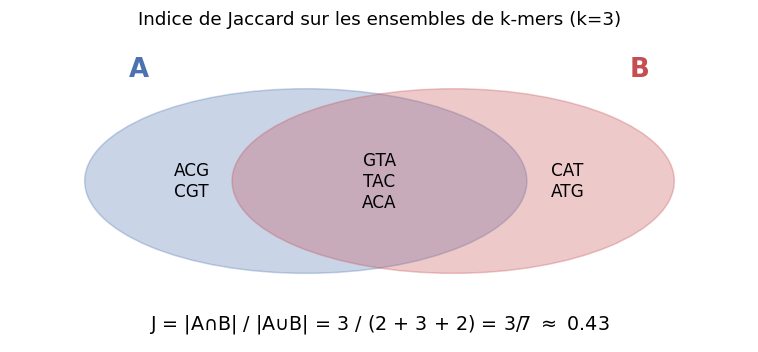

*Mini-exemple : le Jaccard mesure le recouvrement des ensembles de k-mers.*

In [5]:
class Sketch:
    """Classe mere de tous les sketches.

    Le resultat final est range dans self.kmers (frozenset d'entiers), ce qui
    permet de reutiliser la meme fonction jaccard pour tout le monde.
    """
    def __init__(self, size=0, name="sketch"):
        self.name = name
        self.size = size
        self.kmers = frozenset()

    def add_kmers(self, kmers):
        raise NotImplementedError

    def jaccard(self, other):
        inter = len(self.kmers & other.kmers)
        union = len(self.kmers) + len(other.kmers) - inter
        return inter / union if union else 0.0


class AllKmers(Sketch):
    """Sketch de reference : garde TOUS les k-mers -> Jaccard EXACT."""
    def add_kmers(self, kmers):
        self.kmers |= frozenset(kmers)


def build(SketchClass, sequence, k=K, size=1000, use_hash=True, name="sketch"):
    """Construit un sketch a partir d'une sequence."""
    sk = SketchClass(size=size, name=name)
    sk.add_kmers(stream_kmers(sequence, k, use_hash))
    return sk

In [6]:
ref = {name: build(AllKmers, seq, K, name=name) for name, seq in genomes.items()}

print(f"Nombre de k-mers distincts (k={K}) :")
for name, sk in ref.items():
    print(f"  {name:15s} : {len(sk.kmers):,}")

print("\nIndice de Jaccard EXACT :")
pairs = [("A_proche", "B_divergent"),
         ("A_proche", "C_independant"),
         ("B_divergent", "C_independant")]
truth = {}
for a, b in pairs:
    j = ref[a].jaccard(ref[b])
    truth[(a, b)] = j
    print(f"  J({a:13s}, {b:13s}) = {j:.4f}")

Nombre de k-mers distincts (k=21) :
  A_proche        : 49,980
  B_divergent     : 49,980
  C_independant   : 49,980

Indice de Jaccard EXACT :
  J(A_proche     , B_divergent  ) = 0.1508
  J(A_proche     , C_independant) = 0.0000
  J(B_divergent  , C_independant) = 0.0000


On retrouve bien l'intuition : les deux descendants se ressemblent, le génome
indépendant ne ressemble à personne. **Tout l'enjeu des sketches** est de
retrouver ces valeurs sans stocker les dizaines de milliers de k-mers.


## 3. À quoi sert la fonction de hachage ?

Sans hachage, l'entier d'un k-mer reflète directement son **encodage
alphabétique** : les valeurs ne sont pas réparties uniformément. Dès qu'on
sélectionne des k-mers « parce qu'ils sont petits » (MinHash) ou « modulo leur
valeur » (partitions), ce biais fausse l'échantillonnage.

`xorshift64` **disperse** les valeurs de façon ~uniforme. Comme c'est une
*bijection* sur 64 bits, elle ne change **rien** au Jaccard exact (cellule
ci-dessous), mais elle devient essentielle dès qu'on ne garde qu'une **partie**
des k-mers.


In [7]:
a = build(AllKmers, genomes["A_proche"], K, use_hash=False)
b = build(AllKmers, genomes["B_divergent"], K, use_hash=False)
print("Jaccard exact SANS hachage :", round(a.jaccard(b), 4))
print("Jaccard exact AVEC hachage :", round(ref["A_proche"].jaccard(ref["B_divergent"]), 4))
print("=> identique : xorshift64 est une bijection.")
print("   Le hachage devient crucial quand on ne garde qu'une PARTIE des k-mers.")

Jaccard exact SANS hachage : 0.1508
Jaccard exact AVEC hachage : 0.1508
=> identique : xorshift64 est une bijection.
   Le hachage devient crucial quand on ne garde qu'une PARTIE des k-mers.


## 4. Bottom-s MinHash — `Smallers`

**Idée.** On ne garde que les **s plus petites** valeurs de hachage rencontrées.
Comme le hachage répartit les k-mers uniformément, les *s* plus petits hashs
forment un échantillon aléatoire représentatif. Le Jaccard estimé est alors
l'intersection / union de ces deux petits ensembles.

On veut éviter de tout charger en mémoire. **Stratégie naïve :** maintenir
l'ensemble des *s* plus petits vus, en se souvenant de leur **maximum**. Pour
chaque nouveau k-mer : s'il est plus petit que ce maximum, il remplace le
maximum.

> **À coder :** la méthode `add_kmers` de `Smallers`.


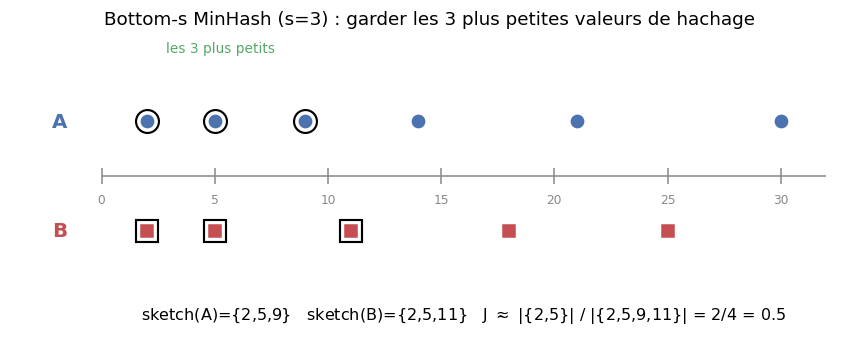

*Mini-exemple : on ne garde que les s plus petites valeurs de hachage de chaque génome.*

In [8]:
class Smallers(Sketch):
    """Bottom-s MinHash : on ne conserve que les `size` plus petites valeurs."""

    def add_kmers(self, kmers):
        kept = set()
        current_max = -1
        for kmer in kmers:
            if kmer in kept:
                continue
            if len(kept) < self.size:
                kept.add(kmer)
                if kmer > current_max:
                    current_max = kmer
            elif kmer < current_max:
                kept.discard(current_max)
                kept.add(kmer)
                current_max = max(kept)
        self.kmers = frozenset(kept)

**Vérification.** On compare l'estimation à la vérité-terrain pour différentes
tailles de sketch *s*. Que constatez-vous quand *s* augmente ?


In [9]:
def estimate_table(SketchClass, sizes, use_hash=True):
    for i, (a, b) in enumerate(pairs):
        print(f"  paire {i+1} : J({a}, {b}) exact = {truth[(a, b)]:.4f}")
    print()
    header = "    s    | " + " | ".join(f" paire {i+1} " for i in range(len(pairs)))
    print(header)
    print("-" * len(header))
    for s in sizes:
        sk = {name: build(SketchClass, seq, K, size=s, use_hash=use_hash)
              for name, seq in genomes.items()}
        cells_ = [f"{sk[a].jaccard(sk[b]):.4f}" for (a, b) in pairs]
        print(f"{s:>8} | " + " | ".join(c.center(8) for c in cells_))

estimate_table(Smallers, [16, 64, 256, 1024, 4096])

  paire 1 : J(A_proche, B_divergent) exact = 0.1508
  paire 2 : J(A_proche, C_independant) exact = 0.0000
  paire 3 : J(B_divergent, C_independant) exact = 0.0000

    s    |  paire 1  |  paire 2  |  paire 3 
--------------------------------------------
      16 |  0.1034  |  0.0000  |  0.0000 
      64 |  0.1327  |  0.0000  |  0.0000 
     256 |  0.1429  |  0.0000  |  0.0000 
    1024 |  0.1384  |  0.0000  |  0.0000 
    4096 |  0.1520  |  0.0000  |  0.0000 


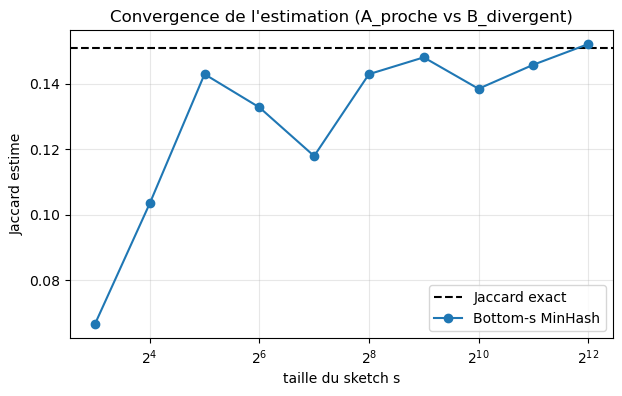

In [10]:
if HAS_PLOT:
    sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
    a, b = pairs[0]
    est = []
    for s in sizes:
        sa = build(Smallers, genomes[a], K, size=s)
        sb = build(Smallers, genomes[b], K, size=s)
        est.append(sa.jaccard(sb))
    plt.figure(figsize=(7, 4))
    plt.axhline(truth[(a, b)], color="k", ls="--", label="Jaccard exact")
    plt.plot(sizes, est, "o-", label="Bottom-s MinHash")
    plt.xscale("log", base=2)
    plt.xlabel("taille du sketch s")
    plt.ylabel("Jaccard estime")
    plt.title(f"Convergence de l'estimation ({a} vs {b})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()
else:
    print("matplotlib indisponible — graphique saute.")

### *(optionnel, intermédiaire)* Accélération avec un tas `heapq`

Rechercher le maximum à chaque remplacement coûte `O(s)`. Un **tas** (`heapq`)
garde le maximum accessible en `O(1)` et permet insertion/suppression en
`O(log s)`. Python n'ayant qu'un tas-*min*, on stocke `-kmer` pour simuler un
tas-*max*.

> **À coder *(bonus)* :** `SmallersHeap.add_kmers`. Le sketch produit doit être
> **identique** à celui de `Smallers`.


In [11]:
import heapq

class SmallersHeap(Sketch):
    """Bottom-s MinHash accelere avec un tas (heapq)."""

    def add_kmers(self, kmers):
        heap = []          # tas-max simule : on stocke -kmer
        seen = set()
        for kmer in kmers:
            if kmer in seen:
                continue
            if len(heap) < self.size:
                seen.add(kmer)
                heapq.heappush(heap, -kmer)
            elif kmer < -heap[0]:
                removed = -heapq.heappushpop(heap, -kmer)
                seen.discard(removed)
                seen.add(kmer)
        self.kmers = frozenset(-x for x in heap)

In [12]:
for name, seq in genomes.items():
    s1 = build(Smallers,     seq, K, size=512)
    s2 = build(SmallersHeap, seq, K, size=512)
    assert s1.kmers == s2.kmers, name
print("Les deux implementations donnent le MEME sketch. OK")

Les deux implementations donnent le MEME sketch. OK


## 5. Partition MinHash — `Partitions`

**Limite du bottom-s :** les *s* valeurs sont liées par un **ordre global**, il
faut donc trier/fusionner pour comparer deux sketches.

**Idée des partitions :** rendre les *s* valeurs **indépendantes**. On découpe
l'espace en *s* **partitions** ; chaque k-mer est affecté à une partition fixée
par `kmer % s`. Dans chaque partition, on ne garde que le **plus petit** k-mer.

Du coup, plus besoin de trier : deux sketches se comparent **partition par
partition** (slot par slot). Le Jaccard estimé est la **fraction de partitions
où les deux minima coïncident**, parmi les partitions non vides. C'est ce
comportement « position par position » qui fait tout l'intérêt des partitions,
donc on **redéfinit** ici la méthode `jaccard`.

> **À coder :** `Partitions.add_kmers` **et** `Partitions.jaccard`.


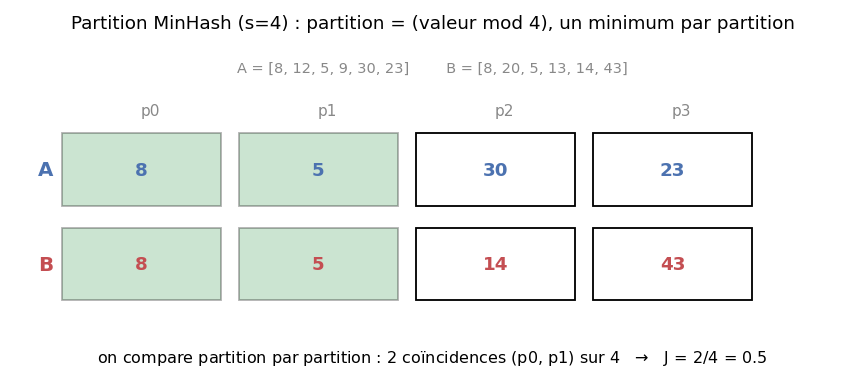

*Mini-exemple : chaque k-mer tombe dans une partition (valeur mod s) ; on compare les minima partition par partition.*

In [13]:
class Partitions(Sketch):
    """Partition MinHash : `size` partitions, un minimum par partition."""

    def add_kmers(self, kmers):
        mins = [None] * self.size
        for kmer in kmers:
            p = kmer % self.size
            if mins[p] is None or kmer < mins[p]:
                mins[p] = kmer
        self.mins = mins

    def jaccard(self, other):
        match = union = 0
        for x, y in zip(self.mins, other.mins):
            if x is not None or y is not None:
                union += 1
                if x is not None and x == y:
                    match += 1
        return match / union if union else 0.0

In [14]:
estimate_table(Partitions, [16, 64, 256, 1024, 4096])

  paire 1 : J(A_proche, B_divergent) exact = 0.1508
  paire 2 : J(A_proche, C_independant) exact = 0.0000
  paire 3 : J(B_divergent, C_independant) exact = 0.0000

    s    |  paire 1  |  paire 2  |  paire 3 
--------------------------------------------
      16 |  0.1875  |  0.0000  |  0.0000 
      64 |  0.1719  |  0.0000  |  0.0000 
     256 |  0.1680  |  0.0000  |  0.0000 
    1024 |  0.1670  |  0.0000  |  0.0000 
    4096 |  0.1626  |  0.0000  |  0.0000 


**À discuter.** Comparez avec le bottom-s : l'estimation est-elle plus proche
de la vérité ? Le coût mémoire est-il le même ? Et le temps de comparaison
(plus besoin de trier) ?


## 6. *(bonus avancé)* HyperMinHash — `HyperMin`

Quand on sélectionne des valeurs **parce qu'elles sont petites**, leur écriture
binaire commence par beaucoup de **zéros**. L'information utile est donc surtout
dans :

1. **la position du premier `1`** (le nombre de zéros de tête), et
2. **quelques bits de poids faible**.

On peut donc compresser un hash de 64 bits en un code de **16 bits** avec une
faible perte. Pour stocker des entiers de taille fixe, on utilise le module
[`array`](https://docs.python.org/3/library/array.html) (`'H'` = *unsigned
short*, 16 bits).

Ici on combine **partitionnement** + **compression**. On garde **exactement le
même** minimum par partition que `Partitions`, mais au lieu de stocker l'entier
de 64 bits, on n'en garde qu'un **code de 16 bits**.

Subtilité importante : les bits de **poids faible** du hash servent déjà à
choisir la partition (`h % size`). On ne peut donc pas les réutiliser comme
empreinte (ils sont identiques pour tous les k-mers d'une partition !). On
encode donc la partie **haute** du hash : `body = h >> p_bits`. Le code de 16
bits combine alors le nombre de zéros de tête de `body` (`rho`) et quelques-uns
de ses bits de poids faible. La fonction `jaccard` est **redéfinie** pour
comparer les registres `array` position par position.

Pour rester simple, on **suppose que toutes les partitions sont remplies** (vrai
dès qu'il y a beaucoup de k-mers) : le Jaccard est alors la **fraction de
partitions identiques**, `match / size`.

*(`size` doit être une puissance de 2. Approximation pédagogique : le vrai
HyperMinHash ajoute une correction statistique des collisions — cf. l'article de
Victor Levallois & co.)*


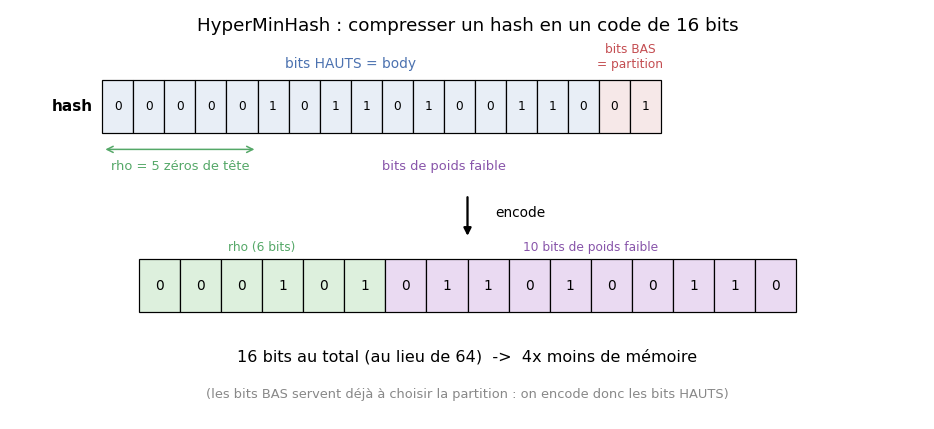

*Mini-exemple : un hash de 64 bits compressé en un code de 16 bits (zéros de tête + bits de poids faible).*

In [15]:
def hmh_code(body, width, r_bits=10, rho_bits=6):
    """Compresse `body` (les bits HAUTS d'un hash, hors bits de partition) en 16 bits.

    bits 15..10 : rho = nombre de zeros de tete de `body` (rho_bits=6)
    bits  9..0  : les r_bits=10 bits de poids faible de `body`
    """
    rho = width if body == 0 else width - body.bit_length()
    rho = min(rho, (1 << rho_bits) - 1)
    return (rho << r_bits) | (body & ((1 << r_bits) - 1))

In [16]:
class HyperMin(Sketch):
    """Partition MinHash compresse : 1 code de 16 bits par partition.
    (On suppose ici que toutes les partitions sont remplies.)"""

    def add_kmers(self, kmers):
        p_bits = self.size.bit_length() - 1
        assert (1 << p_bits) == self.size, "HyperMin: size doit etre une puissance de 2"
        body_bits = 64 - p_bits
        best = [(1 << body_bits) - 1] * self.size   # plus petit `body` par partition
        for h in kmers:
            p = h & (self.size - 1)                 # partition = bits BAS (= h % size)
            body = h >> p_bits                      # bits HAUTS (hors partition)
            if body < best[p]:
                best[p] = body
        self.register = array('H', [hmh_code(b, body_bits) for b in best])

    def jaccard(self, other):
        match = sum(1 for x, y in zip(self.register, other.register) if x == y)
        return match / self.size

In [17]:
print("Comparaison Partitions (64 bits/partition) vs HyperMin (16 bits/partition) :\n")
for s in [256, 1024, 4096]:
    hm = {name: build(HyperMin,   seq, K, size=s) for name, seq in genomes.items()}
    pt = {name: build(Partitions, seq, K, size=s) for name, seq in genomes.items()}
    print(f"s = {s}")
    for (a, b) in pairs:
        print(f"   {a:13s} vs {b:13s} : "
              f"exact={truth[(a, b)]:.4f}  "
              f"partitions={pt[a].jaccard(pt[b]):.4f}  "
              f"hypermin={hm[a].jaccard(hm[b]):.4f}")
    print()

Comparaison Partitions (64 bits/partition) vs HyperMin (16 bits/partition) :

s = 256
   A_proche      vs B_divergent   : exact=0.1508  partitions=0.1680  hypermin=0.1719
   A_proche      vs C_independant : exact=0.0000  partitions=0.0000  hypermin=0.0000
   B_divergent   vs C_independant : exact=0.0000  partitions=0.0000  hypermin=0.0000

s = 1024
   A_proche      vs B_divergent   : exact=0.1508  partitions=0.1670  hypermin=0.1680
   A_proche      vs C_independant : exact=0.0000  partitions=0.0000  hypermin=0.0000
   B_divergent   vs C_independant : exact=0.0000  partitions=0.0000  hypermin=0.0000

s = 4096
   A_proche      vs B_divergent   : exact=0.1508  partitions=0.1626  hypermin=0.1714
   A_proche      vs C_independant : exact=0.0000  partitions=0.0000  hypermin=0.0000
   B_divergent   vs C_independant : exact=0.0000  partitions=0.0000  hypermin=0.0002



### Mémoire : ce qu'on a gagné

Pour une même taille *s*, `HyperMin` stocke des entiers de **16 bits** au lieu
de **64 bits** : ~**4×** moins de mémoire que `Partitions`, pour une précision
voisine.


In [18]:
s = 1024
ex = ref["A_proche"]
sm = build(Smallers,  genomes["A_proche"], K, size=s)
hm = build(HyperMin,  genomes["A_proche"], K, size=s)
print(f"AllKmers       : {len(ex.kmers):>6,} k-mers stockes")
print(f"Smallers (s={s}): {len(sm.kmers):>6} entiers 64 bits ~ {len(sm.kmers) * 8:>6} octets")
print(f"HyperMin (s={s}): {len(hm.register):>6} entiers 16 bits ~ {len(hm.register) * 2:>6} octets")

AllKmers       : 49,980 k-mers stockes
Smallers (s=1024):   1024 entiers 64 bits ~   8192 octets
HyperMin (s=1024):   1024 entiers 16 bits ~   2048 octets


### À mémoire égale, HyperMin est-il plus précis ?

Comparer à **taille** `s` égale est trompeur : `HyperMin` n'utilise alors que
**¼ de la mémoire** de `Partitions`. La vraie question (le bonus du TP) : à
**mémoire égale**, `HyperMin` peut stocker **4× plus de partitions** (16 bits
contre 64). En profite-t-il ?

On mesure, sur plusieurs paires de génomes, le **biais** (erreur moyenne signée)
et l'**écart-type** (dispersion) de l'estimation pour :

* `Partitions` à taille `s` — la référence mémoire ;
* `HyperMin` à taille `s` — ¼ de la mémoire ;
* `HyperMin` à taille `4s` — **même mémoire** que `Partitions` à `s`.

*(Le calcul génère plusieurs génomes : quelques secondes.)*


In [19]:
import statistics

def _kmer_list(seq):
    return list(stream_kmers(seq, K, use_hash=True))

def _exact_J(ka, kb):
    A, B = frozenset(ka), frozenset(kb)
    inter = len(A & B)
    return inter / (len(A) + len(B) - inter)

def _make(SketchClass, kmers, size):
    sk = SketchClass(size=size)
    sk.add_kmers(kmers)
    return sk

def equal_memory_study(n=200_000, s=512, reps=15, mut_rate=0.03):
    """Compare Partitions et HyperMin a TAILLE egale puis a MEMOIRE egale,
    sur `reps` paires de genomes independantes."""
    errP, errHq, errH4 = [], [], []
    for seed in range(reps):
        anc = random_dna(n, seed=1000 + seed)
        ka = _kmer_list(mutate(anc, mut_rate, seed=2 * seed + 1))
        kb = _kmer_list(mutate(anc, mut_rate, seed=2 * seed + 2))
        J = _exact_J(ka, kb)
        errP.append(_make(Partitions, ka, s).jaccard(_make(Partitions, kb, s)) - J)
        errHq.append(_make(HyperMin, ka, s).jaccard(_make(HyperMin, kb, s)) - J)
        errH4.append(_make(HyperMin, ka, 4 * s).jaccard(_make(HyperMin, kb, 4 * s)) - J)

    def stats(d):
        return statistics.mean(d), statistics.pstdev(d), statistics.mean(abs(x) for x in d)

    print(f"{reps} paires de genomes de {n:,} pb (J reel ~ {J:.3f})\n")
    print(f"{'sketch':17s} | memoire | biais   | ecart-type | |erreur| moy")
    print("-" * 65)
    for name, mem, d in [(f"Partitions s={s}",     "x1", errP),
                          (f"HyperMin   s={s}",     "/4", errHq),
                          (f"HyperMin   s={4 * s}", "x1", errH4)]:
        b, sd, mae = stats(d)
        print(f"{name:17s} |   {mem}    | {b:+.4f} |   {sd:.4f}   |   {mae:.4f}")

equal_memory_study()

15 paires de genomes de 200,000 pb (J reel ~ 0.164)

sketch            | memoire | biais   | ecart-type | |erreur| moy
-----------------------------------------------------------------
Partitions s=512  |   x1    | +0.0136 |   0.0130   |   0.0165
HyperMin   s=512  |   /4    | +0.0144 |   0.0125   |   0.0165
HyperMin   s=2048 |   x1    | +0.0112 |   0.0090   |   0.0115


**Ce qu'on observe.**

* À **taille égale** (`s`), `HyperMin` atteint quasiment la même précision que
  `Partitions` pour **4× moins de mémoire** : la compression sur 16 bits est
  presque gratuite.
* À **mémoire égale** (`HyperMin` à `4s`), les partitions 4× plus nombreuses
  **réduisent l'écart-type** → estimation plus précise et plus stable.

**Le revers :** l'empreinte de 16 bits provoque des *collisions* (deux
partitions différentes codées à l'identique) qui **surestiment** légèrement le
Jaccard. Ce biais est négligeable quand les partitions sont **bien peuplées**,
mais grandit si on multiplie les partitions sur un petit génome (peu de k-mers
par partition). Essayez `equal_memory_study(n=50_000)` ou `s=4096` : le gain de
variance peut alors être annulé par le biais.

Le bon compromis dépend donc de la **taille des données** : plus le génome est
gros, plus l'avantage mémoire de HyperMinHash est franc.


## Pour aller plus loin

* **Vraies données.** La fonction ci-dessous télécharge un FASTA depuis NCBI
  (ex. SARS-CoV-2 `NC_045512.2`, ou des bactéries `NZ_CP050202.1`…). Comparez
  les sketches sur de vrais génomes.
* **Temps & mémoire réels.** Hors notebook, préfixez une commande par
  `/usr/bin/time -v` pour lire le *Elapsed time* et le *Maximum resident set
  size*.
* **Questions de complexité.** Quel est le coût de chaque stratégie en fonction
  de *s* (taille du sketch), *k* (taille des k-mers) et *n* (taille de la
  séquence) ?


In [20]:
import urllib.request

def load_ncbi_fasta(accession):
    """Telecharge un FASTA depuis NCBI (necessite une connexion internet)."""
    url = ("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
           f"?db=nuccore&id={accession}&rettype=fasta&retmode=text")
    with urllib.request.urlopen(url) as r:
        text = r.read().decode()
    return "".join(line for line in text.splitlines() if not line.startswith(">"))

# Exemple (a decommenter si vous avez internet) :
# sars = load_ncbi_fasta("NC_045512.2")
# print(len(sars), "pb ;", len(build(AllKmers, sars, K).kmers), "k-mers")
print("Fonction load_ncbi_fasta prete (non appelee).")

Fonction load_ncbi_fasta prete (non appelee).
